<a href="https://colab.research.google.com/github/hgw0215/colab1/blob/main/hgw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [29]:
import os, re, glob
import numpy as np
from PIL import Image

In [5]:
import numpy
import torch

In [17]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [18]:
model=keras.Sequential({
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,activation='softmax')
})

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.compile(optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']        )

In [20]:
history=model.fit(x_train,y_train,epochs=5,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9076 - loss: 0.3183 - val_accuracy: 0.9643 - val_loss: 0.1262
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9535 - loss: 0.1543 - val_accuracy: 0.9742 - val_loss: 0.0896
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9654 - loss: 0.1139 - val_accuracy: 0.9758 - val_loss: 0.0810
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9709 - loss: 0.0923 - val_accuracy: 0.9757 - val_loss: 0.0829
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9745 - loss: 0.0810 - val_accuracy: 0.9790 - val_loss: 0.0740


In [21]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print(f"\n 测试集准确率：{test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9777 - loss: 0.0736

 测试集准确率：0.9777


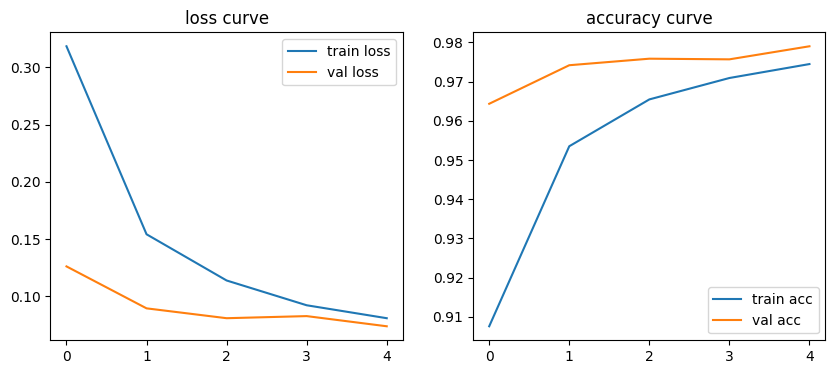

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='train loss')
plt.plot(history.history['val_loss'],label='val loss')
plt.legend()
plt.title('loss curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='train acc')
plt.plot(history.history['val_accuracy'],label='val acc')
plt.legend()
plt.title('accuracy curve')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


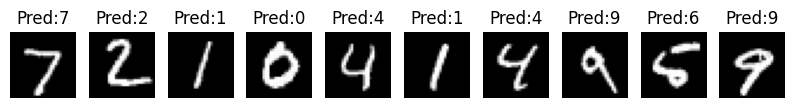

In [25]:
predictions = model.predict(x_test[:10])
plt.figure(figsize=(10,2))
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.imshow(x_test[i],cmap='gray')
  plt.axis('off')
  plt.title(f"Pred:{predictions[i].argmax()}")
plt.show()

In [30]:
from google.colab import files
uploaded = files.upload()
my_image_paths = sorted(uploaded.keys())

Saving 0.jpg to 0.jpg
Saving 1.jpg to 1.jpg
Saving 2.jpg to 2.jpg
Saving 3.jpg to 3.jpg
Saving 4.jpg to 4.jpg
Saving 5.jpg to 5.jpg
Saving 6.jpg to 6.jpg
Saving 7.jpg to 7.jpg
Saving 8.jpg to 8.jpg
Saving 9.jpg to 9.jpg


In [32]:
my_image_paths = my_image_paths[:10]
print(f"共载入 {len(my_image_paths)} 张图片")

共载入 10 张图片


In [41]:
# ★★★ 统一旋转开关 ★★★
# 所有测试图片都会先逆时针旋转这个角度再送进模型。
# 常用值：0（不转）/ 90 / 180 / 270，也可以写 -90 表示顺时针 90 度。
ROTATE_CCW = 90

# Pillow 不同版本里旋转常量的位置不一样，这里做一次兼容
_T90 = getattr(Image, "ROTATE_90", None) or Image.Transpose.ROTATE_90
_T180 = getattr(Image, "ROTATE_180", None) or Image.Transpose.ROTATE_180
_T270 = getattr(Image, "ROTATE_270", None) or Image.Transpose.ROTATE_270


def load_image_rotated(path, rotate_ccw=ROTATE_CCW):
    """
    读入一张图片，并把它逆时针旋转 rotate_ccw 度。

    90 的整数倍走 transpose：无损、不做插值，像素不会被重采样抹糊；
    其它角度走 rotate(expand=True)：画布自动放大以装下整张图。
    """
    img = Image.open(path)
    if rotate_ccw % 90 == 0:
        k = int(rotate_ccw // 90) % 4
        if k == 1:
            img = img.transpose(_T90)        # 逆时针 90°
        elif k == 2:
            img = img.transpose(_T180)       # 逆时针 180°
        elif k == 3:
            img = img.transpose(_T270)       # 逆时针 270°（= 顺时针 90°）
    elif rotate_ccw:
        # fillcolor 的类型要跟图像模式匹配（灰度要给单个整数），否则 Pillow 会报错
        if img.mode not in ("L", "RGB", "RGBA"):
            img = img.convert("RGBA" if "A" in img.getbands() else "RGB")
        fill = {"L": 255, "RGB": (255, 255, 255), "RGBA": (255, 255, 255, 0)}[img.mode]
        img = img.rotate(rotate_ccw, expand=True, resample=Image.BICUBIC, fillcolor=fill)
    return img

In [46]:
def _otsu_threshold(values):
    """纯 numpy 实现的 Otsu 阈值，返回 0~255 之间的分割点。"""
    hist = np.bincount(np.clip(values, 0, 255).astype(np.uint8).ravel(),
                       minlength=256).astype("float64")
    total = hist.sum()
    if total <= 0:
        return 128.0
    idx = np.arange(256, dtype="float64")
    w0 = np.cumsum(hist)
    w1 = total - w0
    s0 = np.cumsum(hist * idx)
    s_total = s0[-1]
    valid = (w0 > 0) & (w1 > 0)
    mu0 = np.zeros(256, dtype="float64")
    mu1 = np.zeros(256, dtype="float64")
    mu0[valid] = s0[valid] / w0[valid]
    mu1[valid] = (s_total - s0[valid]) / w1[valid]
    var_between = np.zeros(256, dtype="float64")
    var_between[valid] = w0[valid] * w1[valid] * (mu0[valid] - mu1[valid]) ** 2
    return float(np.argmax(var_between))


def _border_level(arr, frac=0.06):
    """取图片最外圈一小条像素的中位数，作为“底色”的估计。"""
    h, w = arr.shape
    band = max(2, int(round(min(h, w) * frac)))
    edges = np.concatenate([
        arr[:band, :].ravel(), arr[-band:, :].ravel(),
        arr[:, :band].ravel(), arr[:, -band:].ravel(),
    ])
    return float(np.median(edges))


def _keep_largest_blob(mask):
    """只保留最大的一块连通区域，去掉背景散点噪声（Colab 里有 scipy 时生效）。"""
    try:
        from scipy import ndimage
    except ImportError:
        return mask
    labels, n = ndimage.label(mask)
    if n <= 1:
        return mask
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    return labels == int(sizes.argmax())


def to_mnist_28(path, invert="auto", rotate_ccw=ROTATE_CCW, keep_largest=True,
                debug=False, return_stages=False):
    """
    invert = "auto"   默认，自动处理黑底/白底
             "never"  图片本身就是黑底白字（已经是 MNIST 那种图）
             "always" 强制按白底黑字处理
    """
    img = load_image_rotated(path, rotate_ccw)

    # ---- 读成灰度图；带透明通道的 PNG 把透明区域当背景 ----
    if img.mode in ("RGBA", "LA", "P"):
        rgba = img.convert("RGBA")
        alpha = np.array(rgba)[:, :, 3].astype("float32")
        bg = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
        gray = np.array(Image.alpha_composite(bg, rgba).convert("L")).astype("float32")
        # 垫白底后整张几乎全白、但 alpha 里有内容 → 说明是“透明底 + 白笔画”
        if alpha.min() < 250 and (gray.max() - gray.min()) < 20:
            gray = alpha.copy()
    else:
        gray = np.array(img.convert("L")).astype("float32")

    # ---- ① 去背景：以四周底色为参照，笔画 = |像素 - 底色| ----
    bg_level = _border_level(gray)
    if invert == "auto":
        ink = np.abs(gray - bg_level)        # 背景直接归零，不会再有“灰底”
    elif invert == "always":
        ink = 255.0 - gray
    else:
        ink = gray.copy()

    # ---- ② 对比度拉伸到满量程 0~255 ----
    hi = float(np.percentile(ink, 99.5))
    ink = np.clip(ink / max(hi, 1e-6) * 255.0, 0, 255)

    # ---- ③ Otsu 自动二值化；万一整张被判成笔画就用更严的阈值兜底 ----
    otsu = _otsu_threshold(ink)
    mask = None
    for thr in (otsu, float(np.percentile(ink, 85)), float(np.percentile(ink, 93))):
        cand = ink >= max(thr, 1.0)
        if 0.003 < cand.mean() < 0.45:       # 笔画占比应在 0.3%~45% 之间
            mask = cand
            break
    if mask is None:
        mask = ink >= max(otsu, 1.0)
    if keep_largest:
        mask = _keep_largest_blob(mask)

    if debug:
        print(f"  底色≈{bg_level:5.1f}  Otsu≈{otsu:5.1f}  笔画占比={mask.mean()*100:5.2f}%")

    ink_clean = np.where(mask, ink, 0.0)     # 笔画之外的背景置 0
    if not mask.any():
        empty = np.zeros((28, 28), dtype="float32")
        return (empty, []) if return_stages else empty

    # ---- ④ 裁到笔画外框，等比缩放到 20x20，放进 28x28 画布正中 ----
    ys, xs = np.where(mask)
    ink_clean = ink_clean[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

    h, w = ink_clean.shape
    scale = 20.0 / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    ink_small = np.array(
        Image.fromarray(ink_clean.astype("uint8")).resize((new_w, new_h), Image.LANCZOS)
    ).astype("float32")

    canvas = np.zeros((28, 28), dtype="float32")
    top, left = (28 - new_h) // 2, (28 - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = ink_small

    # ---- ⑤ 按重心平移居中 ----
    total = canvas.sum()
    if total > 0:
        yy, xx = np.mgrid[0:28, 0:28]
        cy = (canvas * yy).sum() / total
        cx = (canvas * xx).sum() / total
        canvas = np.roll(canvas, (int(round(13.5 - cy)), int(round(13.5 - cx))),
                         axis=(0, 1))

    result = canvas / 255.0
    if return_stages:
        stages = [("① 原图(灰度)", gray), ("② 去背景+拉伸", ink),
                  ("③ Otsu 二值", mask.astype("float32") * 255),
                  ("④ 最终 28x28", result * 255)]
        return result, stages
    return result


# 调用处也换掉（建议开着 debug，一眼就能看出预处理有没有走偏）
my_images = np.stack([to_mnist_28(p, invert="auto", debug=True)
                      for p in my_image_paths])

  底色≈199.0  Otsu≈109.0  笔画占比= 1.16%
  底色≈199.0  Otsu≈106.0  笔画占比= 1.39%
  底色≈199.0  Otsu≈111.0  笔画占比= 1.09%
  底色≈198.0  Otsu≈110.0  笔画占比= 1.13%
  底色≈198.0  Otsu≈105.0  笔画占比= 1.59%
  底色≈199.0  Otsu≈102.0  笔画占比= 1.34%
  底色≈199.0  Otsu≈110.0  笔画占比= 1.14%
  底色≈199.0  Otsu≈107.0  笔画占比= 1.26%
  底色≈200.0  Otsu≈ 99.0  笔画占比= 1.90%
  底色≈200.0  Otsu≈108.0  笔画占比= 1.43%


原图和灰度图对比

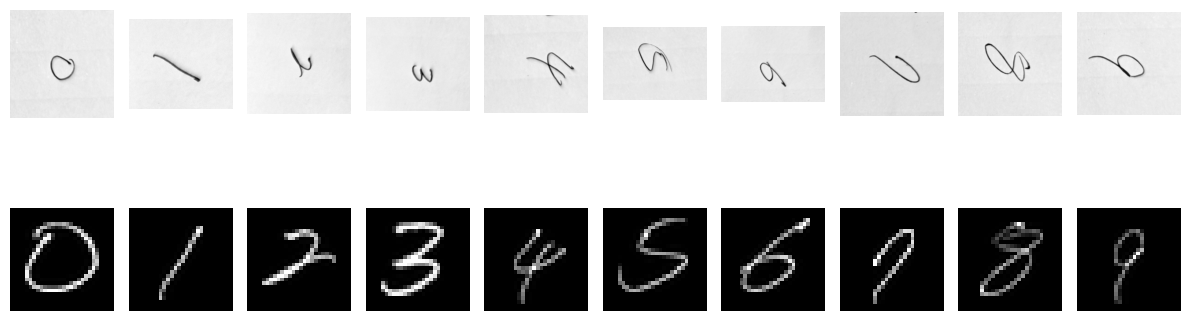

In [50]:
plt.figure(figsize=(12, 5))
for i, path in enumerate(my_image_paths):
    plt.subplot(2, 10, i+1); plt.imshow(Image.open(path).convert("L"), cmap="gray"); plt.axis("off")
    plt.subplot(2, 10, i+11); plt.imshow(my_images[i], cmap="gray"); plt.axis("off")
plt.tight_layout(); plt.show()

处理好的图像预测测试

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


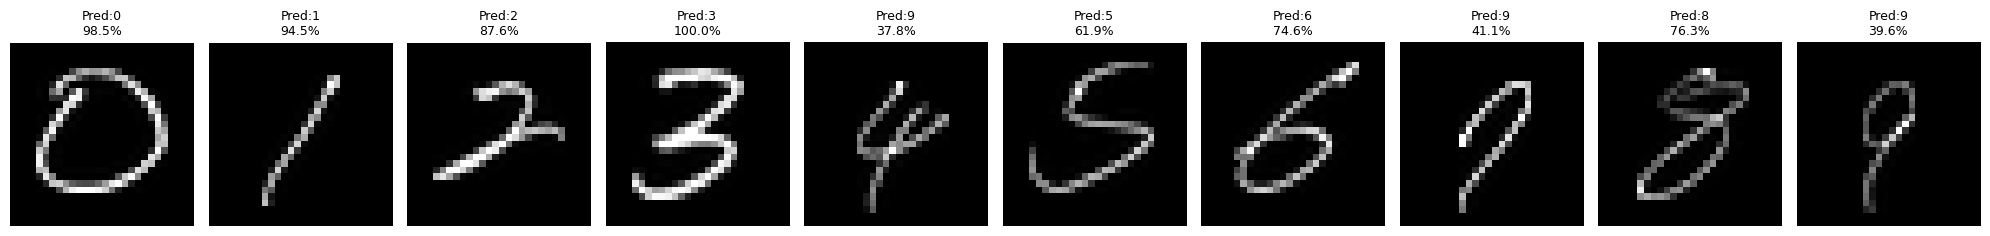

0.jpg                -> 预测 0   置信度 0.9853
1.jpg                -> 预测 1   置信度 0.9451
2.jpg                -> 预测 2   置信度 0.8757
3.jpg                -> 预测 3   置信度 0.9999
4.jpg                -> 预测 9   置信度 0.3779
5.jpg                -> 预测 5   置信度 0.6190
6.jpg                -> 预测 6   置信度 0.7460
7.jpg                -> 预测 9   置信度 0.4109
8.jpg                -> 预测 8   置信度 0.7625
9.jpg                -> 预测 9   置信度 0.3965


In [51]:
my_pred = model.predict(my_images)
my_labels = my_pred.argmax(axis=1)
my_conf = my_pred.max(axis=1)

plt.figure(figsize=(20, 3))
for i in range(len(my_images)):
    plt.subplot(1, len(my_images), i+1)
    plt.imshow(my_images[i], cmap="gray")
    plt.axis("off")
    plt.title(f"Pred:{my_labels[i]}\n{my_conf[i]*100:.1f}%", fontsize=9)
plt.tight_layout()
plt.show()

for path, label, conf in zip(my_image_paths, my_labels, my_conf):
    print(f"{os.path.basename(path):<20} -> 预测 {label}   置信度 {conf:.4f}")

准确率

In [52]:
def true_label_from_name(path):
    m = re.search(r"(\d)", os.path.basename(path))
    return int(m.group(1)) if m else None

true_labels = [true_label_from_name(p) for p in my_image_paths]
if all(l is not None for l in true_labels):
    true_labels = np.array(true_labels)
    print(f"\n你自己的 10 张图片准确率：{(my_labels == true_labels).mean():.4f}")
    for p, t, q in zip(my_image_paths, true_labels, my_labels):
        print(f"[{'OK ' if t == q else '错 '}] {os.path.basename(p)}  真实 {t} / 预测 {q}")
else:
    print("\n文件名里没有数字，跳过自动对比")


你自己的 10 张图片准确率：0.8000
[OK ] 0.jpg  真实 0 / 预测 0
[OK ] 1.jpg  真实 1 / 预测 1
[OK ] 2.jpg  真实 2 / 预测 2
[OK ] 3.jpg  真实 3 / 预测 3
[错 ] 4.jpg  真实 4 / 预测 9
[OK ] 5.jpg  真实 5 / 预测 5
[OK ] 6.jpg  真实 6 / 预测 6
[错 ] 7.jpg  真实 7 / 预测 9
[OK ] 8.jpg  真实 8 / 预测 8
[OK ] 9.jpg  真实 9 / 预测 9
